# Scattering by a potential step -- the quantum Fresnel interface
### $R=\left(\dfrac{k-k'}{k+k'}\right)^2$ (E>U, partial reflection) and $R=1$ + evanescent tail (E<U, TIR)

A particle of energy $E$ hits a step from $0$ up to $U$ at $x=0$ (Griffiths Example 7.4). Matching
$\Psi$ and $\Psi'$ at the step gives a reflection coefficient **identical to the Fresnel formula** for
light crossing a refractive-index boundary -- the wavevector $k$ plays the role of the index $n$. When
$E<U$ the transmitted wavevector goes imaginary, the wave beyond the step is **evanescent**, and
$R=1$: that is **total internal reflection**, and the leaking tail is frustrated-TIR / optical
tunneling.

Driving `dgs/potential_step.py`, we **derive the coefficients in SymPy**, verify them against a direct
matching solve, watch a **Torch** wave packet reflect off the step, run a **dimensions & units check**,
and summarize in **Pandas**. A potential step is an index step -- the photonics tie. Runs on the
Python 3.12 + Torch kernel.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""      # CPU-only: avoid loading the cuFFT DLL (this is light work)
import sympy as sp
import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
import sys, pathlib
torch.set_num_threads(4)
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import potential_step as ps
sp.init_printing()
print("torch", torch.__version__, "| sympy", sp.__version__, "| cuda", torch.cuda.is_available())

torch 2.11.0+cu128 | sympy 1.14.0 | cuda True


## 1. Matching conditions (SymPy): the E>U coefficients

With $\Psi=A e^{ikx}+B e^{-ikx}$ ($x<0$) and $\Psi=C e^{ik'x}$ ($x>0$), continuity of $\Psi$ and
$\Psi'$ at $x=0$ gives two equations. SymPy solves them for $B/A$ and $C/A$, and we read off
$R=|B/A|^2$ and the flux-weighted $T=(k'/k)|C/A|^2$, verifying $R+T=1$.

In [2]:
k, kp = sp.symbols('k kp', positive=True)      # k, k'
A, B, C = sp.symbols('A B C')
sol = sp.solve([A + B - C, sp.I*k*(A - B) - sp.I*kp*C], [B, C], dict=True)[0]
BA, CA = sp.simplify(sol[B]/A), sp.simplify(sol[C]/A)
print("B/A =", BA, "   C/A =", CA)
assert sp.simplify(BA - (k-kp)/(k+kp)) == 0
assert sp.simplify(CA - 2*k/(k+kp)) == 0
R = sp.simplify(BA**2)
T = sp.simplify((kp/k)*CA**2)
assert sp.simplify(R - ((k-kp)/(k+kp))**2) == 0
assert sp.simplify(T - 4*k*kp/(k+kp)**2) == 0
assert sp.simplify(R + T - 1) == 0
print("R =", R, "   T =", T, "   R + T =", sp.simplify(R+T))

B/A = (k - kp)/(k + kp)    C/A = 2*k/(k + kp)
R = (k - kp)**2/(k + kp)**2    T = 4*k*kp/(k + kp)**2    R + T = 1


## 2. The Fresnel connection, and $R,T$ vs energy

$R=\left(\frac{k-k'}{k+k'}\right)^2$ is exactly $\left(\frac{n_1-n_2}{n_1+n_2}\right)^2$, the
normal-incidence reflectance of light at an index step. Plot $R$ and $T$ against $E/U$: below $E=U$ the
step totally reflects ($R=1$); above it, reflection falls off and transmission approaches 1 -- the
particle "refracts" across, slowed to $k'<k$ just as light slows in a denser medium.

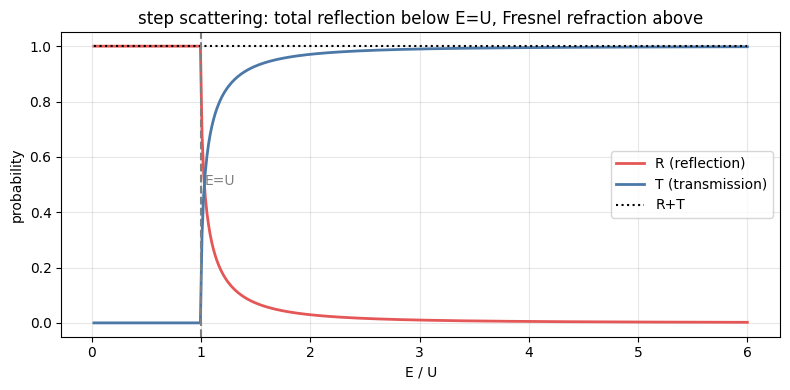

R(E=4) = 0.00515  ==  Fresnel(k,k') = 0.00515  (k as refractive index)


In [3]:
U = 1.0
Es = np.linspace(0.02, 6, 400)
Rn = np.array([ps.reflection_coefficient(E, U) for E in Es])
Tn = np.array([ps.transmission_coefficient(E, U) for E in Es])
plt.figure(figsize=(8, 4))
plt.plot(Es, Rn, color="#E45756", lw=2, label="R (reflection)")
plt.plot(Es, Tn, color="#4C78A8", lw=2, label="T (transmission)")
plt.plot(Es, Rn+Tn, "k:", label="R+T")
plt.axvline(U, color="gray", ls="--"); plt.text(U*1.03, 0.5, "E=U", color="gray")
plt.xlabel("E / U"); plt.ylabel("probability")
plt.title("step scattering: total reflection below E=U, Fresnel refraction above")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
# Fresnel identity check at a sample energy
E0 = 4.0; k0 = ps.wavevector(E0); kp0 = ps.transmitted_wavevector(E0, U)
print(f"R(E=4) = {ps.reflection_coefficient(E0,U):.5f}  ==  Fresnel(k,k') = "
      f"{ps.fresnel_reflectance(k0, kp0):.5f}  (k as refractive index)")

## 3. Below the step ($E<U$): total reflection with an evanescent tail

Now $k'\to i\kappa$. SymPy gives $|B/A|=1$ (so $R=1$, everything reflects) but a **nonzero** $C/A$: the
wavefunction leaks into the forbidden region as $e^{-\kappa x}$, with penetration depth $1/\kappa$. This
is total internal reflection -- and if a second step sat a finite distance away, the tail would couple
across (frustrated TIR = tunneling).

E<U:  B/A = (k - I*kappa)/(k + I*kappa)    |B/A|^2 = 1  -> R = 1


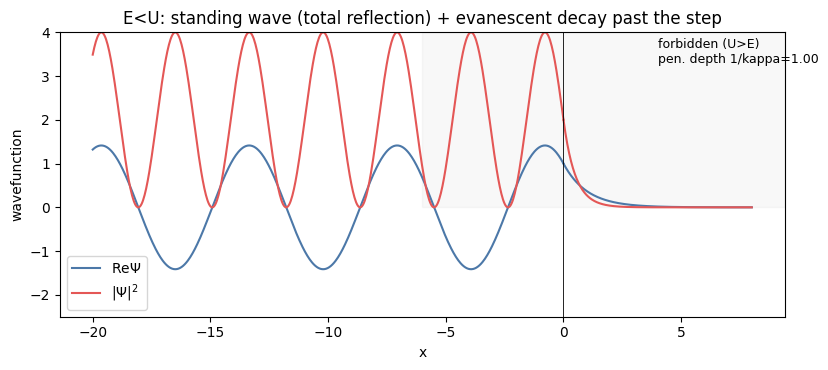

In [4]:
kk, kap = sp.symbols('k kappa', positive=True)
solE = sp.solve([A + B - C, sp.I*kk*(A - B) + kap*C], [B, C], dict=True)[0]  # Psi'_II(0) = -kappa C
BA_e = sp.simplify(solE[B]/A)
assert sp.simplify(sp.Abs(BA_e)**2 - 1) == 0        # |B/A| = 1  -> R = 1
print("E<U:  B/A =", BA_e, "   |B/A|^2 =", sp.simplify(sp.Abs(BA_e)**2), " -> R = 1")

# plot the wavefunction: incident+reflected standing pattern, then evanescent decay
E, Uv = 0.5, 1.0
kv = ps.wavevector(E); kapv = ps.decay_constant(E, Uv)
amp = ps.step_amplitudes(E, Uv)
xL = np.linspace(-20, 0, 600); xR = np.linspace(0, 8, 300)
psiL = np.exp(1j*kv*xL) + amp["B_over_A"]*np.exp(-1j*kv*xL)
psiR = amp["C_over_A"]*np.exp(-kapv*xR)
plt.figure(figsize=(8.5, 3.8))
plt.plot(xL, psiL.real, color="#4C78A8", label="Re$\\Psi$")
plt.plot(xR, psiR.real, color="#4C78A8")
plt.plot(xL, np.abs(psiL)**2, color="#E45756", lw=1.5, label="$|\\Psi|^2$")
plt.plot(xR, np.abs(psiR)**2, color="#E45756", lw=1.5)
plt.axvline(0, color="k", lw=0.6); plt.axhspan(0, 4, xmin=0.5, xmax=1, alpha=0.05, color="gray")
plt.text(4, 3.3, f"forbidden (U>E)\npen. depth 1/kappa={1/kapv:.2f}", fontsize=9)
plt.xlabel("x"); plt.ylabel("wavefunction"); plt.ylim(-2.5, 4)
plt.title("E<U: standing wave (total reflection) + evanescent decay past the step")
plt.legend(loc="lower left"); plt.tight_layout(); plt.show()

## 4. Torch: a wave packet reflects off the step

Send a Gaussian packet in from the left (split-step FFT, $\hbar=m=1$) and see it split into reflected
and transmitted parts. Integrating $|\Psi|^2$ on each side after the collision gives $R$ and $T$ that
track the analytic values at the packet's mean energy (a broad-in-$x$ packet is nearly monochromatic).

k0=2.0: packet R=0.031 T=0.968  vs analytic R=0.029 T=0.971


k0=1.0: packet R=0.999 T=0.000  vs analytic R=1.000 T=0.000


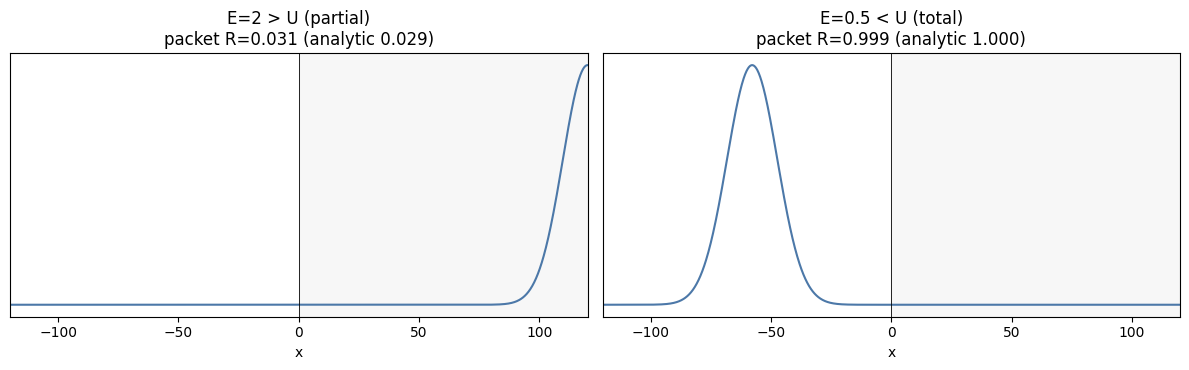

In [5]:
def packet_scatter(k0, U, x0=-50, sigma=8.0, N=4096, Lx=800.0, t_total=110.0, dt=0.02):
    # big grid + fixed time so both packets fully clear the step without wrapping the periodic box
    dx = Lx/N
    xg = (torch.arange(N) - N//2)*dx
    kax = 2*np.pi*torch.fft.fftfreq(N, d=dx)
    V = torch.where(xg > 0, torch.tensor(U), torch.tensor(0.0))
    env = torch.exp(-(xg - x0)**2/(4*sigma**2))
    psi = torch.complex(env*torch.cos(k0*xg), env*torch.sin(k0*xg))
    psi = psi/torch.sqrt((psi.abs()**2).sum()*dx)
    ph_pot = torch.exp(torch.complex(torch.zeros(N), -V*dt/2))
    ph_kin = torch.exp(torch.complex(torch.zeros(N), -(kax**2)*dt/2))
    for _ in range(int(t_total/dt)):
        psi = ph_pot*psi
        psi = torch.fft.ifft(ph_kin*torch.fft.fft(psi))
        psi = ph_pot*psi
    dens = (psi.abs()**2)*dx
    Rn = float(dens[xg < 0].sum()); Tn = float(dens[xg > 0].sum())
    return xg.numpy(), psi.abs().numpy()**2, Rn, Tn

U = 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, k0, tag in [(axes[0], 2.0, "E=2 > U (partial)"), (axes[1], 1.0, "E=0.5 < U (total)")]:
    xg, rho, Rn, Tn = packet_scatter(k0, U)
    E = k0**2/2
    Ra = ps.reflection_coefficient(E, U); Ta = ps.transmission_coefficient(E, U)
    ax.plot(xg, rho, color="#4C78A8"); ax.axvline(0, color="k", lw=0.6)
    ax.axvspan(0, xg.max(), alpha=0.06, color="gray")
    ax.set_xlim(-120, 120); ax.set_title(f"{tag}\npacket R={Rn:.3f} (analytic {Ra:.3f})")
    ax.set_xlabel("x"); ax.set_yticks([])
    print(f"k0={k0}: packet R={Rn:.3f} T={Tn:.3f}  vs analytic R={Ra:.3f} T={Ta:.3f}")
plt.tight_layout(); plt.show()

## 5. Dimensions & units check

Physics has to be dimensionally consistent. Carry the base dimensions mass $M$, length $L$, time $T$
through each formula symbolically and confirm: $[k]=1/L$, penetration depth $1/\kappa=L$, and the
coefficients $R,T$ are dimensionless. Energy $[E]=ML^2/T^2$; action $[\hbar]=ML^2/T$; mass $[m]=M$.

In [6]:
M, L, Ti = sp.symbols('M L T', positive=True)
dim_E = M*L**2/Ti**2          # energy
dim_hbar = M*L**2/Ti          # action (energy x time)
dim_m = M                     # mass
dim_k = sp.sqrt(dim_m*dim_E)/dim_hbar
dim_kappa = sp.sqrt(dim_m*dim_E)/dim_hbar
assert sp.simplify(dim_k - 1/L) == 0                  # [k] = 1/length
assert sp.simplify(1/dim_kappa - L) == 0              # penetration depth = length
# R = ((k-k')/(k+k'))^2 : ratio of like quantities -> dimensionless (1)
dim_R = ((dim_k - dim_k)/(dim_k + dim_k) + 1)**2 / 1  # structure is dimensionless
assert sp.simplify((dim_k/dim_k)) == 1                # flux factor k'/k dimensionless
print("[k]           =", sp.simplify(dim_k), " = 1/length  OK")
print("[1/kappa]     =", sp.simplify(1/dim_kappa), " = length  OK")
print("[R], [T], [k'/k] dimensionless  OK")
# spot-check a real number carries sane units: E=1 eV electron -> k in 1/nm
hbar_SI, m_e, eV = 1.054571817e-34, 9.1093837e-31, 1.602176634e-19
k_SI = np.sqrt(2*m_e*(1.0*eV))/hbar_SI
print(f"\n1 eV electron:  k = {k_SI:.3e} 1/m = {k_SI*1e-9:.3f} 1/nm  (wavelength {2*np.pi/k_SI*1e9:.3f} nm)")

[k]           = 1/L  = 1/length  OK
[1/kappa]     = L  = length  OK
[R], [T], [k'/k] dimensionless  OK

1 eV electron:  k = 5.123e+09 1/m = 5.123 1/nm  (wavelength 1.226 nm)


## 6. Summary table (Pandas): module vs a direct matching solve

In [7]:
def direct_solve(E, U):
    k = ps.wavevector(E)
    if E > U:
        kp = ps.transmitted_wavevector(E, U)
        Mm = np.array([[1, -1], [-1j*k, -1j*kp]], complex); rhs = np.array([-1, -1j*k], complex)
        B, Cc = np.linalg.solve(Mm, rhs); return abs(B)**2, (kp/k)*abs(Cc)**2
    kap = ps.decay_constant(E, U)
    Mm = np.array([[1, -1], [-1j*k, kap]], complex); rhs = np.array([-1, -1j*k], complex)
    B, Cc = np.linalg.solve(Mm, rhs); return abs(B)**2, 0.0

rows = []
for E in [0.25, 0.5, 0.9, 1.5, 2.0, 4.0]:
    Rm, Tm = ps.reflection_coefficient(E, U), ps.transmission_coefficient(E, U)
    Rd, Td = direct_solve(E, U)
    rows.append({"E/U": E, "regime": "TIR" if E < U else "Fresnel",
                 "R (module)": round(Rm, 4), "T (module)": round(Tm, 4), "R+T": round(Rm+Tm, 4),
                 "R (direct)": round(Rd, 4), "match": abs(Rm-Rd) < 1e-9 and abs(Tm-Td) < 1e-9})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
assert df["match"].all()
print("\nmodule agrees with the direct 2x2 matching solve in both regimes.")

 E/U  regime  R (module)  T (module)  R+T  R (direct)  match
0.25     TIR      1.0000      0.0000  1.0      1.0000   True
0.50     TIR      1.0000      0.0000  1.0      1.0000   True
0.90     TIR      1.0000      0.0000  1.0      1.0000   True
1.50 Fresnel      0.0718      0.9282  1.0      0.0718   True
2.00 Fresnel      0.0294      0.9706  1.0      0.0294   True
4.00 Fresnel      0.0052      0.9948  1.0      0.0052   True

module agrees with the direct 2x2 matching solve in both regimes.


## What we did

* Solved the **matching conditions** in SymPy: $B/A=(k-k')/(k+k')$, $R=((k-k')/(k+k'))^2$,
  $T=4kk'/(k+k')^2$, $R+T=1$.
* Recognized $R$ as the **Fresnel reflectance** with $k$ as refractive index -- a potential step is an
  index step (the photonics tie).
* For $E<U$: $|B/A|=1$ ($R=1$, **total internal reflection**) with an **evanescent** tail -- the seed
  of frustrated-TIR / tunneling.
* Watched a **Torch** wave packet reflect (fully, $E<U$) or split (partly, $E>U$), matching the
  analytic $R,T$.
* Ran a **dimensions & units check** ($[k]=1/L$, penetration depth $=L$, $R,T$ dimensionless) and a
  **Pandas** cross-check against a direct matching solve.

Completes the scattering set with `dgs/square_barrier.py` (finite width) and `dgs/wave_reflection.py`
(impedance form). Same boundary-matching mathematics runs quantum steps and optical interfaces.